### Your first neural network

For the last coding assignment, you'll need to implement a neural network. We'll look at a relatively simple binary classification problem.

1. Remember: scale your data appropriately

2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

2. Decide your optimization metric.

3. Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)

4. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

5. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

6. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.


### A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

- **3. The HiggsML challenge** Branching out of astrophysics, let's mess around with a dataset of simulated but  realistic events from the ATLAS particle detector at CERN.
    - Data are at `solutions/higgs.tar.gz` (you need to uncompress with `tar -czvf`)
    - There are $N_{\rm samples} = 2.5\times 10^5$ entries with $N_{\rm features}=30$ features each. 
    - The taks is that of classifying these features against a set of labels, which are either `s` (source) or `b` (background).
    - For some info on both the physics and the dataset see [this document](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf); includes a description of the features and how data have been padded (-999) for missing values.
    - This dataset was part of a challenge that run on Kaggle in 2014: https://higgsml.ijclab.in2p3.fr/ 



I link non funzionano più ma ho trovato questo https://indico.cern.ch/event/382895/contributions/910922/attachments/763482/1047453/tr150519_davidRousseau_CERNvisit_HiggsML.pptx.pdf ,dovrebbe essere lo stesso dataset

Un dataset simulato di processi Higgs -> tau + tau. Il background è una mixture di tre fenomeni:
-Z boson -> tau tau
-top top -> lepton tau 
-W -> lepton tau

La evaluation metric per la challenge è stata la approximate median significance (AMS)  \
$AMS = \sqrt{2(s + b + b_r)log(1 + \frac{s}{b+b_r}) - s}$ --------- $b_r$ = 10, s e b sono true positive e false positive rates



Se b >> s e questo è il caso, AMS si riduce a $\frac{s}{\sqrt{b}}$

Lista delle feature a: https://opendata.cern.ch/record/328. Le features possono essere non definite, in quel caso è stato settato un valore di -999 per tenerlo fuori dal range delle altre variabili

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pylab as plt 
import pandas as pd #uso panda per crearmi un dizionario dei data
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV


I0000 00:00:1784472874.418852   29364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784472874.424820   29364 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784472875.011824   29364 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784472877.263614   29364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [38]:
#Il vincitore aveva AMS = 3.806
winner_AMS = 3.806
def calc_AMS(y_true, y_model_pred, w_test):
    #somma dei pesi dei True positive
    s = np.sum(w_test[(y_true == 1) & (y_model_pred ==1)])
    #somma dei pesi dei falsi positivi
    b = np.sum(w_test[(y_true == 0) & (y_model_pred ==1)])

    b_r = 10.0

    log = np.log(1 + (s / (b + b_r)))
    ams = np.sqrt(2 * ((s + b + b_r) * log - s))

    return ams

In [4]:
df = pd.read_csv('higgs.csv')
#Non tutte le colonne hanno feature fisiche, escludiamo la 0 che è l'Id delll'evento, i pesi e i label che sono i target
feature_cols = [col for col in df.columns if col not in ['EventId', 'Weight', 'Label']]
#Estriamo i valori delle features e i label li trasformiamo in int
# signal -> 1
# background -> 0
X = df[feature_cols].values
y = df['Label'].map({'s':1, 'b':0}).values
w = df['Weight'].values

N_samples = int(2.5e5)
N_features = 30

df.keys()

Index(['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt',
       'Weight', 'Label'],
      dtype='str')

In [5]:
#Adesso scaliamo i dati, usando lo StandardScaler. Prima però trasformiamo i -999 in NaN che poi diventeranno '0.0' 
#che sarà il valore medio della colonna scalata
X[X==-999] = np.nan

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.3, random_state=42
)

#L'imputer è una classe di sklearn per gestire i nan
#https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

imputer = SimpleImputer(strategy='median') #gli diciamo di gestirlo con la mediana della colonna
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# Una prima rete non ottimizzata
Creiamo una neural network senza ottimizzare i parametri con la cross-validation. Uso Sklearn con MLP classifier

In [6]:
nopt_clf = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(50,25), 
    activation='relu',  #Relu come activation function per i neuroni f(x) = max(0, x)
    solver='adam',
    alpha=0, #per adesso non regolarizziamo
    learning_rate_init=0.001,
    early_stopping=True,
    random_state=42,
    verbose = True,
    max_iter=200)

In [7]:
nopt_clf.fit(X_train, y_train)

Iteration 1, loss = 0.43213751
Validation score: 0.828286
Iteration 2, loss = 0.38076439
Validation score: 0.835086
Iteration 3, loss = 0.37140545
Validation score: 0.836286
Iteration 4, loss = 0.36669451
Validation score: 0.838000
Iteration 5, loss = 0.36357554
Validation score: 0.838000
Iteration 6, loss = 0.36158986
Validation score: 0.839200
Iteration 7, loss = 0.35987533
Validation score: 0.838286
Iteration 8, loss = 0.35892675
Validation score: 0.838114
Iteration 9, loss = 0.35733254
Validation score: 0.839143
Iteration 10, loss = 0.35692258
Validation score: 0.839714
Iteration 11, loss = 0.35590832
Validation score: 0.840343
Iteration 12, loss = 0.35521423
Validation score: 0.838800
Iteration 13, loss = 0.35468278
Validation score: 0.839771
Iteration 14, loss = 0.35400218
Validation score: 0.841543
Iteration 15, loss = 0.35345682
Validation score: 0.840914
Iteration 16, loss = 0.35314217
Validation score: 0.840457
Iteration 17, loss = 0.35248158
Validation score: 0.840171
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


(0.8, 1.0)

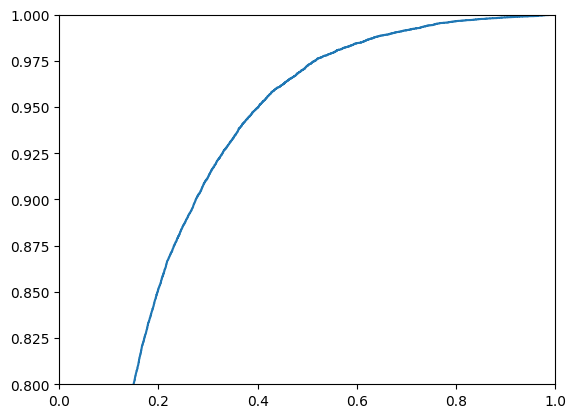

In [8]:
y_prob_nopt = nopt_clf.predict_proba(X_test)[:, 1]
y_pred_nopt = nopt_clf.predict(X_test)
fpr_nopt, tpr_nopt, _ = roc_curve(y_test, y_prob_nopt)
auc_base = roc_auc_score(y_test, y_prob_nopt)

plt.plot(fpr_nopt, tpr_nopt)
plt.xlim(0,1)
plt.ylim(0.8,1)

In [9]:
AMS_nopt = calc_AMS(y_test, y_pred_nopt, w_test)
print(AMS_nopt)

1.5599314391318655


# Iperparametri ottimizzati con CV

In [10]:
from scipy.stats import randint
import random

#Definiamo un clf base
clf = sklearn.neural_network.MLPClassifier(max_iter = 40, early_stopping = True, random_state = 42, verbose = True)

#RandomizedSearchCV: esplora random in una serie di strutture
architecture_list = []

#strutture ad un layer
for i in range(10):
    n1 = random.randint(10,150)
    architecture_list.append((n1,))

#strutture a due layer "ad imbuto"
for i in range(15):
    n1 = random.randint(32,128)
    n2 = random.randint(10, n1)
    architecture_list.append((n1,n2))

#triplo strato
for i in range(10):
    n1 = random.randint(64, 128)
    n2 = random.randint(32, 64)
    n3 = random.randint(10, 32)
    architecture_list.append((n1, n2, n3))


param_dist = {
    'hidden_layer_sizes': architecture_list,
    'alpha': [0.00001, 0.0001, 0.001, 0.01] #regularization parameter L2
}
from sklearn.model_selection import RandomizedSearchCV


random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=8, #8 combinazioni
    cv=3, #3 fold
    scoring='roc_auc',           # ottimizziamo per l'AUC, anche se il nostro sarà AMS
    n_jobs=-1,                   # usa tutti i core della CPU
    random_state=42,
    verbose=3
)

In [11]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization

Iteration 1, loss = 0.42011815
Validation score: 0.834629
Iteration 2, loss = 0.37493993
Validation score: 0.836114
Iteration 3, loss = 0.36817432
Validation score: 0.839371
Iteration 4, loss = 0.36385204
Validation score: 0.838457
Iteration 5, loss = 0.36154609
Validation score: 0.839029
Iteration 6, loss = 0.35906020
Validation score: 0.840514
Iteration 7, loss = 0.35737927
Validation score: 0.841486
Iteration 8, loss = 0.35651011
Validation score: 0.840686
Iteration 9, loss = 0.35537182
Validation score: 0.838914
Iteration 10, loss = 0.35457269
Validation score: 0.842000
Iteration 11, loss = 0.35386384
Validation score: 0.840400
Iteration 12, loss = 0.35317991
Validation score: 0.841714
Iteration 13, loss = 0.35222027
Validation score: 0.840629
Iteration 14, loss = 0.35158792
Validation score: 0.839771
Iteration 15, loss = 0.35115894
Validation score: 0.841200
Iteration 16, loss = 0.35065760
Validation score: 0.841943
Iteration 17, loss = 0.35024512
Validation score: 0.843257
Iterat

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier... verbose=True)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [1e-05, 0.0001, ...], 'hidden_layer_sizes': [(100,), (66,), ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None cha

In [12]:
print(random_search.best_params_)
best_model = random_search.best_estimator_
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_rs = best_model.predict(X_test) 
AMS_rs = calc_AMS(y_test, y_pred_rs, w_test)
print(AMS_rs)

{'hidden_layer_sizes': (75, 25), 'alpha': 1e-05}
1.589847624533613


Il modello trovato dal RandomSearch è un doppiolayer (113,95). Tuttavia l'AMS è ancora basso. Il legame è dovuto al fatto che abbiamo ottimizzato rispetto all'AUC, ma stiamo usando come standard l'AMS (non è implementato in sklearn mi sembra, ho cercato e non dovrebbe esserci perché è stato fatto apposta per la challenge) \
\
Il classificatore usano una soglia probabilistica a 0.5, ma il bg in questo dataset è molto più alto del segnale, dunque per ottenere un AMS migliore serve trovare un taglio ottimale per l'AMS

In [13]:
#Per trovare un optimal cut per l'AMS non possiamo usare direttamente il test set, uso il training set e lo divido ulteriormente
#tenendo un validation set per l'optimal cut
X_sub_train, X_val, y_sub_train, y_val, w_sub_train, w_val = train_test_split(
    X_train, y_train, w_train, test_size=0.15, random_state=42,
)
clf_optimized = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(113, 95), 
    activation='relu',
    solver='adam',
    alpha=1e-05,
    learning_rate_init=0.001,
    max_iter=50,                  
    early_stopping=True,          
    random_state=42,
    verbose=True                  
)

clf_optimized.fit(X_sub_train, y_sub_train)

y_prob_val = clf_optimized.predict_proba(X_val)[:, 1]

Iteration 1, loss = 0.41199044
Validation score: 0.831664
Iteration 2, loss = 0.37189172
Validation score: 0.835361
Iteration 3, loss = 0.36445524
Validation score: 0.830118
Iteration 4, loss = 0.36095397
Validation score: 0.835899
Iteration 5, loss = 0.35841606
Validation score: 0.835630
Iteration 6, loss = 0.35571118
Validation score: 0.838252
Iteration 7, loss = 0.35365183
Validation score: 0.836437
Iteration 8, loss = 0.35210182
Validation score: 0.839462
Iteration 9, loss = 0.35115134
Validation score: 0.839731
Iteration 10, loss = 0.34917529
Validation score: 0.838857
Iteration 11, loss = 0.34788718
Validation score: 0.836504
Iteration 12, loss = 0.34724114
Validation score: 0.839193
Iteration 13, loss = 0.34546878
Validation score: 0.837378
Iteration 14, loss = 0.34489742
Validation score: 0.839059
Iteration 15, loss = 0.34389328
Validation score: 0.838790
Iteration 16, loss = 0.34288756
Validation score: 0.840000
Iteration 17, loss = 0.34172663
Validation score: 0.836975
Iterat

In [14]:
#Cerchiamo l'optimal cutoff per l'AMS 
cutoffs = np.linspace(0.01,0.99,100)
ams_ax = []

for k in cutoffs:
    y_pred_cut = (y_prob_val > k).astype(int)
    ams_curr = calc_AMS(y_val, y_pred_cut, w_val)
    ams_ax.append(ams_curr)

#cerchiamo il massimo
idx_max = np.argmax(ams_ax)
cutoff_opt = cutoffs[idx_max]

Abbiamo trovato un cutoff_opt sul validation test, ora calcoliamo l'AMS sul test set

In [15]:
y_prob_test = clf_optimized.predict_proba(X_test)[:,1]
y_pred_test = (y_prob_test > cutoff_opt).astype(int)
ams_opt = calc_AMS(y_test, y_pred_test, w_test)
print(ams_opt)

1.9139178566234247


Lasciamoci ispirare dal vincitore. Da quanto ho trovato Gábor Melis ha raggiunto quell'AMS con un ensemble di reti neurali tramite Bagging. Proviamo a fare una cosa simile

In [16]:
from sklearn.ensemble import BaggingClassifier
n_estimators = 10
X_sub_train, X_val, y_sub_train, y_val, w_sub_train, w_val = train_test_split(
    X_train, y_train, w_train, test_size=0.15, random_state=42
)
clf_optimized = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(113, 95), 
    activation='relu',
    solver='adam',
    alpha=1e-05,
    learning_rate_init=0.001,
    max_iter=50,                  
    early_stopping=True,
    verbose=True                  
)

#creiamo l'ensemble
ensemble_clf = BaggingClassifier(
    estimator = clf_optimized,
    n_estimators = n_estimators,
    max_samples=1.0,
    bootstrap = True,
    n_jobs = -1,
    random_state = 42,
    verbose = 3 
)

ensemble_clf.fit(X_sub_train, y_sub_train)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:   52.9s remaining:  2.6min
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:  1.1min remaining:   38.9s


Iteration 1, loss = 0.46444774
Validation score: 0.814691
Iteration 2, loss = 0.40317134
Validation score: 0.821891
Iteration 3, loss = 0.39300018
Validation score: 0.825148
Iteration 4, loss = 0.38800560
Validation score: 0.827034
Iteration 5, loss = 0.38471564
Validation score: 0.827548
Iteration 6, loss = 0.38190446
Validation score: 0.829348
Iteration 7, loss = 0.38002788
Validation score: 0.829005
Iteration 8, loss = 0.37789018
Validation score: 0.828833
Iteration 9, loss = 0.37642600
Validation score: 0.828919
Iteration 10, loss = 0.37516163
Validation score: 0.829948
Iteration 11, loss = 0.37388298
Validation score: 0.832091
Iteration 12, loss = 0.37281533
Validation score: 0.833119
Iteration 13, loss = 0.37141364
Validation score: 0.834148
Iteration 14, loss = 0.37054032
Validation score: 0.834062
Iteration 15, loss = 0.36966678
Validation score: 0.832262
Iteration 16, loss = 0.36890872
Validation score: 0.831319
Iteration 17, loss = 0.36790360
Validation score: 0.834148
Iterat

[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  1.4min finished


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",MLPClassifier... verbose=True)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",3


In [17]:
y_prob_val_ensemble = ensemble_clf.predict_proba(X_val)[:, 1]

cutoffs = np.linspace(0.01, 0.99, 100)
ams_ensemble_val = []

for k in cutoffs:
    y_pred_cut = (y_prob_val_ensemble > k).astype(int)
    ams_curr = calc_AMS(y_val, y_pred_cut, w_val) # Richiama la tua funzione calc_AMS
    ams_ensemble_val.append(ams_curr)

idx_max = np.argmax(ams_ensemble_val)
cutoff_opt_ensemble = cutoffs[idx_max]

y_prob_test_ensemble = ensemble_clf.predict_proba(X_test)[:, 1]
y_pred_test_ensemble = (y_prob_test_ensemble > cutoff_opt_ensemble).astype(int)

ams_ensemble = calc_AMS(y_test, y_pred_test_ensemble, w_test)
auc_ensemble = roc_auc_score(y_test, y_prob_test_ensemble)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.6s
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.6s remaining:    1.8s
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:    0.8s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.9s finished


In [18]:
print(f"AMS dell'Ensemble: {ams_ensemble}")
print(f"AUC ensemble: {auc_ensemble}")

AMS dell'Ensemble: 1.9203395576885955
AUC ensemble: 0.9095025387969038


Il risultato di 1.92 non è malaccio (sarei arrivato 1530esimo circa su 1784). Ma proviamo anche un altro tipo di approccio. Informandomi un po' online ho trovato che in questo tipo di analisi si effettua un "jet binning" (https://arxiv.org/pdf/1312.4535). Un jet è un fascio di particelle e il nostro dataset tiene conto di quanti jet c'erano in ogni evento nella feature "PRI_jet_num". Spesso viene fatto di addestrare modelli separati per numeri differenti di jet e poi farli confrontare. Nel nostro caso i jet variano da 0 a 3, dunque possiamo pensare di addestrare 4 reti. Provo a fare quattro reti, una per ogni jet-bin, composta da un ensemble bagging di 10 per ogni bin.

In [19]:
df = pd.read_csv('higgs.csv')
#Non tutte le colonne hanno feature fisiche, escludiamo la 0 che è l'Id delll'evento, i pesi e i label che sono i target
feature_cols = [col for col in df.columns if col not in ['EventId', 'Weight', 'Label']]
#Estriamo i valori delle features e i label li trasformiamo in int
# signal -> 1
# background -> 0
X = df[feature_cols].values
y = df['Label'].map({'s':1, 'b':0}).values
w = df['Weight'].values

N_samples = int(2.5e5)
N_features = 30

df.keys()

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.3, random_state=42
)


In [20]:
import joblib
jet_bins = [0, 1, "2+"] #accorpo i jet 2 e 3 perché sennò l'ultimo dataset sarebbe troppo piccolo
jet_num_idx = feature_cols.index('PRI_jet_num')
conf_ens = {} #per salvare le metriche di ciascun ensemble
s_tot = 0.0
b_tot = 0.0

#per salvarci i modelli addestrati
pipeline = {}

all_y_test = []
all_y_pred = []
all_w_test = []

for jet_val in jet_bins:
    print(f"sono nel canale {jet_val}")

    if jet_val == "2+":
        mask_train = X_train[:, jet_num_idx] >= 2
        mask_test = X_test[:, jet_num_idx] >= 2
    else:
        mask_train = X_train[:, jet_num_idx] == jet_val
        mask_test = X_test[:, jet_num_idx] == jet_val
    #ho avuto un po' di problemi con le colonne -999. Più che altro ad esempio in jet_bin = 0, ci sono colonne
    #intere di feature con solo -999. Alla fine rimuovo le feature se sono fatte solo da -999

    X_tr_bin = X_train[mask_train]
    
    valid_col_idx = np.where(~(X_tr_bin == -999.0).all(axis=0))[0]

    X_tr_bin_filt = X_tr_bin[:, valid_col_idx]
    X_te_bin_filt = X_test[mask_test][:, valid_col_idx]

    y_tr_bin = y_train[mask_train]
    w_tr_bin = w_train[mask_train]
    y_te_bin = y_test[mask_test]
    w_te_bin = w_test[mask_test]

    X_tr_bin_filt[X_tr_bin_filt == -999.0] = np.nan
    X_te_bin_filt[X_te_bin_filt == -999.0] = np.nan

    #validation set
    X_sub_tr, X_val, y_sub_tr, y_val, w_sub_tr, w_val = train_test_split(
        X_tr_bin_filt, y_tr_bin, w_tr_bin, test_size=0.15, random_state=42, stratify=y_tr_bin
    )

    imputer = SimpleImputer(strategy='median')
    X_sub_tr_imp = imputer.fit_transform(X_sub_tr)
    X_val_imp = imputer.transform(X_val)
    X_te_bin_imp = imputer.transform(X_te_bin_filt)

    scaler = StandardScaler()
    X_sub_tr_scaled = scaler.fit_transform(X_sub_tr_imp)
    X_val_scaled = scaler.transform(X_val_imp)
    X_te_bin_scaled = scaler.transform(X_te_bin_imp)

    #Uso come base la MLP che abbiamo ottimizzato
    base =  sklearn.neural_network.MLPClassifier(
        hidden_layer_sizes=(113, 95),
        activation='relu',
        solver='adam',
        alpha=1e-05,
        learning_rate_init=0.001,
        max_iter=40,               
        early_stopping=True
    )

    jet_ensemble = BaggingClassifier(
        estimator=base,
        n_estimators=10,
        max_samples=1.0,
        bootstrap=True,
        n_jobs=-1,                 
        random_state=42,
        verbose=0
    )
    jet_ensemble.fit(X_sub_tr_scaled, y_sub_tr)

    y_prob_val = jet_ensemble.predict_proba(X_val_scaled)[:, 1]

    cutoffs = np.linspace(0.01, 0.99, 100)
    ams_val_list = []

    for k in cutoffs:
        preds_v = (y_prob_val > k).astype(int)
        ams_val_list.append(calc_AMS(y_val, preds_v, w_val))

    cutoff_opt = cutoffs[np.argmax(ams_val_list)]

    y_prob_test = jet_ensemble.predict_proba(X_te_bin_scaled)[:, 1]
    y_pred_test = (y_prob_test > cutoff_opt).astype(int)

    # dal comitato del canale
    s_test_bin = np.sum(w_te_bin[(y_te_bin == 1) & (y_pred_test == 1)])
    b_test_bin = np.sum(w_te_bin[(y_te_bin == 0) & (y_pred_test == 1)])
    
    ams_test_bin = calc_AMS(y_te_bin, y_pred_test, w_te_bin)
    auc_test_bin = roc_auc_score(y_te_bin, y_prob_test)

    #vogliamo salvarci anche i risultati dei singoli canali, per questo il dizionario di prima
    conf_ens[f"{jet_val}"] = {
        'AUC': auc_test_bin,
        'Cutoff': cutoff_opt,
        'AMS': ams_test_bin,
        's': s_test_bin,
        'b': b_test_bin
    }

    #ma anche cumulare i risultati per dare un risultato finale
    s_tot += s_test_bin
    b_tot += b_test_bin

    all_y_test.append(y_te_bin)
    all_y_pred.append(y_pred_test)
    all_w_test.append(w_te_bin)

    pipeline[f"{jet_val}"] = {
        'feature_usate': valid_col_idx, 
        'imputer': imputer,
        'scaler': scaler,
        'ensemble': jet_ensemble,
        'soglia_ams': cutoff_opt
    }

sono nel canale 0
sono nel canale 1
sono nel canale 2+


In [21]:
savfil = "higgs_ensemble.joblib"
joblib.dump(pipeline, savfil)

y_test_globale = np.concatenate(all_y_test)
y_pred_globale = np.concatenate(all_y_pred)
w_test_globale = np.concatenate(all_w_test)

ams_tot = calc_AMS(y_test_globale, y_pred_globale, w_test_globale)
print(ams_tot)

1.7678669350602154


E' venuto peggio! L'unica teoria che mi viene in mente è che nel caso precedente i jet 1,2+ usavano comunque l'informazione del jet 0 per distinguere il fondo anche nella loro casistica, mentre così i singoli bin sono miopi rispetto agli altri bin. Probabilmente anche la misura del base classifier andrebbe ottimizzata per ciascun jet bin singolarmente per evitare overfitting

# Ottimizziamo direttamente l'AMS?

Il problema principale dell'usare l' AMS come loss function è che basandosi su s e b ha dei conteggi discreti che la rendono non derivabile (dunque non utilizzabile con un approccio di gradient descent). Basta rendere s e b funzioni lisce facendo la somma dei pesi con l'output probabilistico. Siccome la radice di AMS è positiva, piuttosto che massimizzare l'ams minimizziaamo -(AMS)^2, sennò con la radice si ha che ho sqrt x al denominatore che se si avvicina a valori piccoli potrebbe esplodere. Uso Keras perché ha il parametro "loss" da mettere come funzione

In [41]:
def ams_loss(y_true, y_pred):

    labels = tf.cast(y_true[:, 0], tf.float32)
    weights = tf.cast(y_true[:, 1], tf.float32)

    probs = tf.squeeze(y_pred)
    

    s = tf.reduce_sum(weights * labels * probs)
    b = tf.reduce_sum(weights * (1.0 - labels) * probs)
    

    b_r = 10.0
    

    eps = 1e-7

    log_arg = 1.0 + (s / (b + b_r + eps))
    log_val = tf.math.log(log_arg)
    

    ams_sq = 2.0 * ((s + b + b_r) * log_val - s)

    return -ams_sq

In [44]:
y_train_weighted = np.column_stack([y_train, w_train])
y_test_weighted = np.column_stack([y_test, w_test])

def create_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(113, activation='relu'),
        keras.layers.Dense(95, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss=ams_loss)
    return model

n_estimators = 5 
models = []

for i in range(n_estimators):
    model = create_model()
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    model.fit(X_train[idx], y_train_weighted[idx], epochs=40, batch_size=2048, verbose=0)
    models.append(model)

y_prob_all = np.array([m.predict(X_test).flatten() for m in models])
y_prob_ensemble = np.mean(y_prob_all, axis=0)


cutoffs = np.linspace(0.01, 0.99, 100)
ams_ensemble_scores = [calc_AMS(y_test, (y_prob_ensemble > cut).astype(int), w_test) for cut in cutoffs]

print(f"AMS ensemble {np.max(ams_ensemble_scores):.4f}")

2344/2344 ━━━━━━━━━━━━━━━━━━━━ 1s 571us/step
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step
AMS ensemble 0.6048
